In [1]:
# # Dependency installation (required by the assignment)
# %pip install -q "transformers==4.53.2" "peft==0.11" "accelerate>=0.33" "datasets>=2.19"
# %pip install -q sacrebleu "bert-score==0.3.13" nltk sentencepiece sacremoses regex

# # IndicTransToolkit provides IndicProcessor + IndicDataCollator 
# # (pre/post-processing for IndicTrans2)
# %pip install -q git+https://github.com/VarunGumma/IndicTransToolkit.git

# print("Dependencies installed.")

In [2]:
import gc
import torch

# Delete large objects if they exist, so Python can actually free them
for name in ["trainer", "model", "refit_model", "refit_trainer", "base", "merged"]:
    if name in globals():
        del globals()[name]
        print(f"Deleted {name}")

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.synchronize()
    print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"Reserved:  {torch.cuda.memory_reserved()/1e9:.2f} GB")

Allocated: 0.00 GB
Reserved:  0.00 GB


In [ ]:
import os, re, gc, time, random, unicodedata, warnings
import numpy as np
import pandas as pd
import transformers
import torch

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print(f"torch: {torch.__version__} | transformers: {transformers.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | VRAM: {p.total_memory/1e9:.1f} GB")


torch: 2.7.1+cu118 | transformers: 4.53.2 | device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU | VRAM: 8.6 GB


In [ ]:
from pathlib import Path

CONFIG = {
    "DATA_DIR": ".",               
    "SRC_LANG": "san_Deva",        # Sanskrit in Devanagari
    "TGT_LANG": "eng_Latn",        # English in Latin script
    "MAX_LEN": 128,

    "MODEL_ID": "ai4bharat/indictrans2-indic-en-dist-200M",
    "OUTPUT_DIR": "it2_san_en_lora",
    "MERGED_DIR": "it2_san_en_merged",

    "USE_LORA": False,
    "LORA_R": 32,
    "LORA_ALPHA": 64,
    "LORA_DROPOUT": 0.1,
    "LORA_TARGETS": ["q_proj", "k_proj", "v_proj", "out_proj"],
    "EPOCHS": 5,
    "TRAIN_BS": 16,
    "EVAL_BS": 32,
    "GRAD_ACCUM": 2,

    "PRECISION": "fp16",
    "ATTN_IMPL": "sdpa",
    "NUM_WORKERS": 6,
    "GRAD_CKPT": False,
    "LR": 2e-4,
    "LABEL_SMOOTHING": 0.01,
    "WARMUP_RATIO": 0.05,
    "PATIENCE": 4,
    "EVAL_WITH_GENERATE": True,

    "LR_FULL_FT": 3e-5,

    # ===== decoding =====
    "NUM_BEAMS" : 5,
    "LENGTH_PENALTY" : 1.0,
    "NO_REPEAT_NGRAM" : 3,

    # ===== misc =====
    "SEED" : SEED
}

def resolve(cands):
    for c in cands:
        p = Path(CONFIG["DATA_DIR"]) / c
        if p.exists():
            return str(p)
    raise FileNotFoundError(f"None of {cands} found in {CONFIG['DATA_DIR']}!")

PATHS = {
    "train_sa": resolve(["train_sa_10000.csv", "train_sp.csv"]),
    "train_en": resolve(["train_en_10000.csv", "train_en.csv"]),
    "dev_sa": resolve(["dev_sa_1000.csv", "dev_sp.csv"]),
    "dev_en": resolve(["dev_en_1000.csv", "dev_en.csv"]),
    "test_sa": resolve(["test_sa_1000.csv", "test_sp.csv"]),
    "test_en": resolve(["test_en_1000.csv", "test_en.csv"]),
}

print("Resolved files:")
for k, v in PATHS.items():
    print(f"{k:10s} -> {os.path.basename(v)}")




Resolved files:
train_sa   -> train_sa_10000.csv
train_en   -> train_en_10000.csv
dev_sa     -> dev_sa_1000.csv
dev_en     -> dev_en_1000.csv
test_sa    -> test_sa_1000.csv
test_en    -> test_en_1000.csv


In [5]:
def clean_text(st: str) -> str:
    if not isinstance(st, str):
        return ""
    s = unicodedata.normalize("NFC", st)  # canonical Unicode form (essential for Devanagari)
    s = s.replace("\r", "").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def load_pairs(sa_path, en_path=None, split="train"):
    sa = pd.read_csv(sa_path)
    sa["Sentence_sa"] = sa["Sentence_sa"].map(clean_text)
    if en_path is None:
        sa = sa[sa["Sentence_sa"].str.len() > 0].reset_index(drop=True)
        sa = sa.rename(columns={"Source_id": "Sentence_sa"})
        return sa
    en = pd.read_csv(en_path)
    en["Sentence_en"] = en["Sentence_en"].map(clean_text)
    en = en[en["Sentence_en"].str.len() > 0]
    df = sa.merge(en, on="Source_id", how="inner")  # Source_id aligns the pair
    df = df.drop_duplicates(subset=["Sentence_sa", "Sentence_en"])
    return df.reset_index(drop=True)

train_df = load_pairs(PATHS["train_sa"], PATHS["train_en"]).drop_duplicates()
dev_df = load_pairs(PATHS["dev_sa"], PATHS["dev_en"]).drop_duplicates()
test_df = load_pairs(PATHS["test_sa"], PATHS["test_en"]).drop_duplicates()

print(f"Train {len(train_df)} | dev {len(dev_df)} | public test (has references) {len(test_df)}")

sa_len = train_df["Sentence_sa"].map(len)
en_len = train_df["Sentence_en"].map(len)
print(f"sa_len mean={sa_len.mean():.1f} g95={sa_len.quantile(0.95):.1f} | "
      f"en_len mean={en_len.mean():.1f} g95={en_len.quantile(0.95):.1f}")

train_df.head(3)


Train 9982 | dev 1000 | public test (has references) 1000
sa_len mean=68.8 g95=145.9 | en_len mean=69.9 g95=152.0


,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."


In [6]:
train_set = set(train_df["Sentence_sa"])
overlap_dev = set(dev_df["Sentence_sa"]) & train_set
overlap_test = set(test_df["Sentence_sa"]) & train_set
print(f"Dev overlap: {len(overlap_dev)} | Test overlap: {len(overlap_test)}")

Dev overlap: 10 | Test overlap: 7


In [7]:
train_set = set(train_df["Sentence_sa"])
leak_sa = (set(dev_df["Sentence_sa"]) | set(test_df["Sentence_sa"])) & train_set

before = len(train_df)
train_df = train_df[~train_df["Sentence_sa"].isin(leak_sa)].reset_index(drop=True)
print(f"Removed {before - len(train_df)} leaked rows from train ({len(train_df)} remain)")

Removed 18 leaked rows from train (9964 remain)


In [8]:
import difflib
# crude check: any dev/test sentence with high overlap with common train n-grams
train_sa_norm = train_df["Sentence_sa"].str.lower().str.strip()
dev_sa_norm = dev_df["Sentence_sa"].str.lower().str.strip()
near_dupes = dev_sa_norm[dev_sa_norm.isin(train_sa_norm)]
print(f"Near-dupe check (case/whitespace-insensitive): {len(near_dupes)}")

Near-dupe check (case/whitespace-insensitive): 0


In [9]:
assert train_df["Source_id"].is_unique, "Duplicate Source_id — merge may misalign pairs!"

ratio = train_df["Sentence_en"].str.split().str.len() / train_df["Sentence_sa"].str.split().str.len().clip(lower=1)
bad = train_df[(ratio < 0.3) | (ratio > 3.0)]
print(f"{len(bad)} suspicious length-ratio pairs")

175 suspicious length-ratio pairs


In [10]:
from IndicTransToolkit import IndicProcessor
from transformers import AutoTokenizer

# Reuse the same preprocessor and tokenizer used for training
ip_train = IndicProcessor(inference=False)
tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)

preprocessed = ip_train.preprocess_batch(
    train_df["Sentence_sa"].tolist(),
    src_lang=CONFIG["SRC_LANG"],
    tgt_lang=CONFIG["TGT_LANG"],
    is_target=False
)

lens = [len(tokenizer(s)["input_ids"]) for s in preprocessed]
lens = pd.Series(lens)
print(f"{(lens > 256).sum()} / {len(lens)} exceed MAX_LEN")

0 / 9964 exceed MAX_LEN


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# IndicProcessor / IndicDataCollator import path changed across toolkit versions; try both.
try:
    from IndicTransToolkit import IndicProcessor, IndicDataCollator
except Exception:
    from IndicTransToolkit.processor import IndicProcessor  
    from IndicTransToolkit import IndicDataCollator

tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_ID"], trust_remote_code=True)

def load_it21(model_id):
    # Prefer PyTorch SDPA attention (faster / lower VRAM on Ampere); fall back to eager if rejected.
    attempts = [CONFIG["ATTN_IMPL"], "eager"] if CONFIG["ATTN_IMPL"] != "eager" else ["eager"]
    for attn in attempts:
        try:
            m = AutoModelForSeq2SeqLM.from_pretrained(
                model_id, trust_remote_code=True, attn_implementation=attn
            )
            print(f"Loaded with attn_implementation={attn}")
            return m
        except Exception as e:
            print(f" attn={attn} unavailable ({type(e).__name__}); trying next ...")
    raise RuntimeError("Could not load the model with any attention implementation.")

model = load_it21(CONFIG["MODEL_ID"]).to(DEVICE)

ip_infer = IndicProcessor(inference=True)  # for translating (adds tags, masks entities)

def count_params(m):
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    # For PEFT models, also count adapter params 
    if hasattr(m, 'peft_config'):
        trainable = sum(p.numel() for n, p in m.named_parameters() if 'lora' in n or p.requires_grad)
    return total, trainable

tot, trainable = count_params(model)
print(f"Model {CONFIG['MODEL_ID']}:")
print(f"Total parameters: {tot:,} ({tot/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:,} ({trainable/1e6:.1f} M)")
if DEVICE == "cuda":
    print(f"VRAM allocated after load: {torch.cuda.memory_allocated()/1e9:.2f} GB "
          f"/ {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")


Loaded with attn_implementation=sdpa
Model ai4bharat/indictrans2-indic-en-dist-200M:
Total parameters: 211,780,608 (211.8 M)
Trainable parameters: 211,780,608 (211.8 M)
VRAM allocated after load: 0.85 GB / 8.59 GB


In [14]:
@torch.inference_mode()
def translate(sentences, batch_size=32, num_beams=None, length_penalty=None,
              no_repeat_ngram=None, max_len=None, processor=None):
    num_beams = num_beams or CONFIG["NUM_BEAMS"]
    length_penalty = length_penalty if length_penalty is not None else CONFIG["LENGTH_PENALTY"]
    no_repeat_ngram = no_repeat_ngram if no_repeat_ngram is not None else CONFIG["NO_REPEAT_NGRAM"]
    max_len = max_len or CONFIG["MAX_LEN"]
    processor = processor or ip_infer

    model.eval()
    use_fp16 = (DEVICE == "cuda")
    outputs = []
    for i in range(0, len(sentences), batch_size):
        chunk = sentences[i:i + batch_size]
        batch = processor.preprocess_batch(chunk, src_lang=CONFIG["SRC_LANG"],
                                           tgt_lang=CONFIG["TGT_LANG"])
        enc = tokenizer(batch, truncation=True, padding="longest",
                        max_length=max_len, return_tensors="pt").to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=use_fp16):
            gen = model.generate(**enc, num_beams=num_beams,
                                 length_penalty=length_penalty,
                                 no_repeat_ngram_size=no_repeat_ngram,
                                 max_length=max_len, early_stopping=True)
        with tokenizer.as_target_tokenizer():
            out = tokenizer.batch_decode(gen, skip_special_tokens=True,
                                         clean_up_tokenization_spaces=True)
        outputs.extend(processor.postprocess_batch(out, lang=CONFIG["TGT_LANG"]))
    return [o.strip() for o in outputs]

# smoke test on 3 dev sentences
_demo = translate(dev_df["Sentence_sa"].tolist()[:3],batch_size=3)
for s,p in zip(dev_df["Sentence_sa"].tolist()[:3],_demo):
    print("SA:",s[:80]);print("EN:",p[:80]);print()

SA: ते वीराः ।
EN: They are HEROES.

SA: 'इन्फ़ैनेट् लूप्' इतीदं व्यवस्थां निरुत्तरां कारयति ।
EN: The'infinite loop'causes the system to fail.

SA: ततस्तस्य गात्रे निष्ठीवं दत्वा तेन वेत्रेण शिर आजघ्नुः।
EN: Then he put him to the gallows and struck him on the head with the spear.



In [ ]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sacrebleu.metrics import BLEU as SacreBLEU
import numpy as np

_sacrebleu = SacreBLEU()  # instantiate once, reuse

def bleu_nltk(preds, refs):
    preds = list(preds)
    refs = list(refs)
    if not preds or not refs:
        return {"bleu_corpus": 0.0, "bleu_sentence_mean": 0.0}

    # Corpus BLEU via sacreBLEU (standard tokenization, comparable to literature)
    corpus = _sacrebleu.corpus_score(preds, [refs]).score / 100.0  # scale to 0-1 to match old range

    # Sentence-level mean BLEU (NLTK, smoothed) — kept for per-sentence diagnostics
    sm = SmoothingFunction().method4
    sent = np.mean([sentence_bleu([r.split()], p.split(), smoothing_function=sm)
            for p, r in zip(preds, refs)])

    return {"bleu_corpus": corpus, "bleu_sentence_mean": float(sent)}

def bertscore_f1(preds, refs, batch_size=64):
    from bert_score import score as bs_score

    preds = list(preds)
    refs = list(refs)

    try:
        P, R, F1 = bs_score(preds, refs, lang="en", rescale_with_baseline=True,
                            batch_size=batch_size, verbose=False)
    except KeyError:
        print("Baseline rescaling failed; falling back to rescale_with_baseline=False")
        P, R, F1 = bs_score(preds, refs, lang="en", rescale_with_baseline=False,
                            batch_size=batch_size, verbose=False)
    return float(F1.mean())

@torch.inference_mode()
def timed_translate(sentences, batch_size=32, **gen_kwargs):
    # Translate and return (predictions, total_seconds, sentences_per_second)
    if DEVICE == "cuda":
        _ = translate(sentences[:batch_size], batch_size=batch_size, **gen_kwargs)  # warm-up
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    preds = translate(sentences, batch_size=batch_size, **gen_kwargs)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = time.perf_counter() - t0
    return preds, dt, len(sentences) / dt

def report(preds, refs, seconds=None, model_for_params=None, do_bertscore=True, tag=""):
    r = bleu_nltk(preds, refs)
    if do_bertscore:
        r["bertscore_f1"] = bertscore_f1(preds, refs)
    if seconds is not None:
        r["seconds"] = seconds
    if model_for_params is not None:
        total, trainable = count_params(model_for_params)
        r["total_params"] = total
        r["trainable_params"] = trainable
    return r


def print_summary(dev_scores=None, test_scores=None, model_for_params=None):
    total = trainable = None
    if model_for_params is not None:
        total, trainable = count_params(model_for_params)
    elif dev_scores is not None and "total_params" in dev_scores:
        total = dev_scores["total_params"]
        trainable = dev_scores.get("trainable_params", total)
    elif test_scores is not None and "total_params" in test_scores:
        total = test_scores["total_params"]
        trainable = test_scores.get("trainable_params", total)

    print("=" * 60)
    if total is not None:
        print(f"{'Total Parameters (full model)':32}: {total:,}")
        print(f"{'Trainable Parameters (fine-tuned)':32}: {trainable:,}")
    if dev_scores is not None and "seconds" in dev_scores:
        print(f"{'Inference Time (Dev)':32}: {dev_scores['seconds']:.2f} sec")
    if test_scores is not None and "seconds" in test_scores:
        print(f"{'Inference Time (Test)':32}: {test_scores['seconds']:.2f} sec")
    if dev_scores is not None:
        print(f"{'Dev BLEU (NLTK corpus)':32}: {dev_scores['bleu_corpus']:.4f}")
        if "bertscore_f1" in dev_scores:
            print(f"{'Dev BERTScore (F1)':32}: {dev_scores['bertscore_f1']:.4f}")
    if test_scores is not None:
        print(f"{'Test BLEU (NLTK corpus)':32}: {test_scores['bleu_corpus']:.4f}")
        if "bertscore_f1" in test_scores:
            print(f"{'Test BERTScore (F1)':32}: {test_scores['bertscore_f1']:.4f}")
    print("=" * 60)


In [17]:
baseline_preds, baseline_time, baseline_sps = timed_translate(
    dev_df["Sentence_sa"].tolist(), batch_size=CONFIG["EVAL_BS"]
)
print(f"Zero-shot dev inference: {baseline_time:.1f}s ({baseline_sps:.1f} sent/s)")

baseline_scores = report(
    baseline_preds,
    dev_df["Sentence_en"].tolist(),
    seconds=baseline_time,
    model_for_params=model,
    do_bertscore=True,
    tag="zero-shot dev"
)


Zero-shot dev inference: 85.0s (11.8 sent/s)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [18]:
from datasets import Dataset

ip_train = IndicProcessor(inference=False)  # training-mode processor

def build_dataset(df):
    src = ip_train.preprocess_batch(
        df["Sentence_sa"].tolist(),
        src_lang=CONFIG["SRC_LANG"],
        tgt_lang=CONFIG["TGT_LANG"],
        is_target=False
    )
    tgt = ip_train.preprocess_batch(
        df["Sentence_en"].tolist(),
        src_lang=CONFIG["TGT_LANG"],
        tgt_lang=CONFIG["SRC_LANG"],
        is_target=True
    )
    return Dataset.from_dict({"sentence_SRC": src, "sentence_TGT": tgt})

def tokenize_fn(batch):
    model_inputs = tokenizer(
        batch["sentence_SRC"], truncation=True, padding=False,
        max_length=CONFIG["MAX_LEN"]
    )
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            batch["sentence_TGT"], truncation=True, padding=False,
            max_length=CONFIG["MAX_LEN"]
        )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

print(train_df[:5])
train_ds = build_dataset(train_df).map(tokenize_fn, batched=True,
                                       remove_columns=["sentence_SRC","sentence_TGT"])
dev_ds = build_dataset(dev_df).map(tokenize_fn, batched=True,
                                   remove_columns=["sentence_SRC","sentence_TGT"])

print("Tokenised:", train_ds, dev_ds, sep="\n")


   Source_id                                        Sentence_sa  \
0          1                         "Ctrl, S नुत्वा रक्षन्तु।"   
1          2                     गुरुः छात्रान् एकवारं पाठयति ।   
2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...   
3          4        वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।   
4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...   

                                         Sentence_en  
0                              Save it with Ctrl, S.  
1         Teacher will teach the students only once.  
2  To recreate this animation, I have to take two...  
3    I will choose Colors options by clicking on it.  
4  "See the example here - one mountain, four vil...  


Map:   0%|          | 0/9964 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenised:
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 9964
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1000
})


In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback, DataCollatorForSeq2Seq
# ---- label smoothing ----
_model_ls=0
if hasattr(model, "set_label_smoothing"):
    model.set_label_smoothing(CONFIG["LABEL_SMOOTHING"])
else:
    _model_ls = CONFIG["LABEL_SMOOTHING"]

# ---- Diagnostic: verify LoRA target module names actually exist on this model ----
# If they don't, PEFT silently attaches LoRA to 0 modules and training does
# nothing useful — this produces exactly the "LoRA scores the same as
# baseline/full-FT" symptom that looks like a modeling problem but is
# actually a wiring problem. Always check this before trusting a LoRA run.
_candidate_modules = sorted({n.split(".")[-1] for n, _ in model.named_modules()
                              if any(t in n for t in ["proj", "attn", "fc1", "fc2"])})
print("Attention/FFN submodule name suffixes found on this model:", _candidate_modules)
_missing_targets = [t for t in CONFIG["LORA_TARGETS"] if t not in _candidate_modules]
if CONFIG["USE_LORA"] and _missing_targets:
    print(f"WARNING: LORA_TARGETS {_missing_targets} were NOT found among the model's "
          f"submodule names above -> LoRA will attach to 0 modules for these targets. "
          f"Fix CONFIG['LORA_TARGETS'] to match names actually printed above before trusting this run.")

if CONFIG["USE_LORA"]:
    lora_cfg = LoraConfig(
        r=CONFIG["LORA_R"], lora_alpha=CONFIG["LORA_ALPHA"],
        lora_dropout=CONFIG["LORA_DROPOUT"], bias="none",
        task_type="SEQ_2_SEQ_LM", inference_mode=False,
        target_modules=CONFIG["LORA_TARGETS"]
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    _tot, _train = count_params(model)
    _ratio = _train / max(_tot, 1)
    print(f"LoRA trainable ratio: {_ratio:.4%}")
    if _ratio < 0.0005:
        print(f"WARNING: trainable ratio looks too small for r={CONFIG['LORA_R']} -- "
              f"double check LORA_TARGETS matched real module names above.")

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model, padding="longest",
    pad_to_multiple_of=8, label_pad_token_id=-100
)

# ---- optional BLEU for checkpoint selection ----
compute_metrics = None
if CONFIG["EVAL_WITH_GENERATE"]:
    from sacrebleu.metrics import BLEU as SB_BLEU
    sb = SB_BLEU()
    def compute_metrics(eval_preds):
        labels = eval_preds.label_ids
        preds = eval_preds.predictions
        labels = np.where(labels == -100 ,tokenizer.pad_token_id,labels)
        with tokenizer.as_target_tokenizer():
            dp = [x.strip() for x in tokenizer.batch_decode(preds, skip_special_tokens=True)]
            dl = [x.strip() for x in tokenizer.batch_decode(labels, skip_special_tokens=True)]
        return {"BLEU": sb.corpus_score(dp, [dl]).score}

# ---- learning rate: full fine-tuning and LoRA need very different LRs ----
run_lr = CONFIG.get("LR_LORA", 2e-4) if CONFIG["USE_LORA"] else CONFIG.get("LR_FULL_FT", 3e-5)

# Hard guard: a bool, string, or out-of-range value here silently becomes a
# garbage learning rate (e.g. True -> 1.0) and will visibly blow up training
# (NaN eval loss, ~0 BLEU by epoch 1). Fail loudly instead of training on junk.
assert isinstance(run_lr, float) and not isinstance(run_lr, bool), (
    f"run_lr must be a float, got {type(run_lr)} = {run_lr!r}. "
    f"Check CONFIG['LR_FULL_FT'] / CONFIG['LR_LORA'] were not overwritten "
    f"somewhere else in the notebook, and restart the kernel + rerun from "
    f"the CONFIG cell if in doubt."
)
assert 1e-7 < run_lr < 1e-2, (
    f"run_lr={run_lr} is outside a sane range for fine-tuning a pretrained "
    f"seq2seq model -- double check CONFIG before training."
)
print(f"Using learning_rate={run_lr} ({'LoRA' if CONFIG['USE_LORA'] else 'full fine-tune'})")

# ---- TrainingArguments ----
targ_kwargs = dict(
    output_dir=CONFIG["OUTPUT_DIR"], overwrite_output_dir=True,
    num_train_epochs=CONFIG["EPOCHS"],
    per_device_train_batch_size=CONFIG["TRAIN_BS"],
    per_device_eval_batch_size=CONFIG["EVAL_BS"],
    gradient_accumulation_steps=CONFIG["GRAD_ACCUM"],
    learning_rate=run_lr, weight_decay=CONFIG.get("WEIGHT_DECAY", 0),
    lr_scheduler_type="cosine", warmup_ratio=CONFIG["WARMUP_RATIO"],
    label_smoothing_factor=_model_ls,
    fp16=(DEVICE == "cuda" and CONFIG["PRECISION"] == "fp16"),
    bf16=(DEVICE == "cuda" and CONFIG["PRECISION"] == "bf16"),
    dataloader_num_workers=2,
    dataloader_pin_memory=(DEVICE == "cuda"),
    gradient_checkpointing=CONFIG["GRAD_CKPT"],
    logging_steps=50,
    save_total_limit=CONFIG.get("CKPT_AVERAGE_LAST_N", 1),  # keep several checkpoints for averaging
    metric_for_best_model="BLEU" if CONFIG.get("EVAL_WITH_GENERATE", False) else "eval_loss",
    greater_is_better=CONFIG.get("EVAL_WITH_GENERATE", False),
    load_best_model_at_end=True,  # otherwise EarlyStoppingCallback stops early but never
                                   # restores the best checkpoint -- you'd keep whatever
                                   # epoch training happened to end on
    predict_with_generate=CONFIG.get("EVAL_WITH_GENERATE", False),
    generation_num_beams=CONFIG["NUM_BEAMS"],
    generation_max_length=CONFIG["MAX_LEN"],
    group_by_length=True, report_to="none", seed=CONFIG["SEED"]
)

try:
    args = Seq2SeqTrainingArguments(eval_strategy="epoch", save_strategy="epoch", **targ_kwargs)
except TypeError:
    args = Seq2SeqTrainingArguments(evaluation_strategy="epoch", save_strategy="epoch", **targ_kwargs)


class CustomSeq2SeqTrainer(Seq2SeqTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        # Remove num_items_in_batch as IndicTrans doesn't support it
        if num_items_in_batch is not None:
            inputs.pop("num_items_in_batch", None)
        return super().compute_loss(model, inputs, return_outputs=return_outputs)

trainer = CustomSeq2SeqTrainer(
    model=model, args=args, data_collator=collator,
    train_dataset=train_ds, eval_dataset=dev_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=CONFIG["PATIENCE"])]
)

import json

# Train once
train_result = trainer.train()

# Save metrics
with open("train_result.json", "w") as f:
    json.dump(train_result.metrics, f)

# Save log history (training curves)
with open("log_history.json", "w") as f:
    json.dump(trainer.state.log_history, f)

# Save model + tokenizer
trainer.save_model(CONFIG["OUTPUT_DIR"])
tokenizer.save_pretrained(CONFIG["OUTPUT_DIR"])


Attention/FFN submodule name suffixes found on this model: ['encoder_attn', 'encoder_attn_layer_norm', 'fc1', 'fc2', 'k_proj', 'out_proj', 'q_proj', 'self_attn', 'self_attn_layer_norm', 'v_proj']
Using learning_rate=3e-05 (full fine-tune)


Epoch,Training Loss,Validation Loss,Bleu
1,1.765200,1.681837,25.582381
2,1.566500,1.607394,26.984949
3,1.358100,1.620814,26.852679
4,1.288200,1.616962,27.724565
5,1.226700,1.616997,27.358371


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


('it2_san_en_lora\\tokenizer_config.json',
 'it2_san_en_lora\\special_tokens_map.json',
 'it2_san_en_lora\\dict.SRC.json',
 'it2_san_en_lora\\dict.TGT.json',
 'it2_san_en_lora\\model.SRC',
 'it2_san_en_lora\\model.TGT',
 'it2_san_en_lora\\added_tokens.json')

In [ ]:
import json

# Load metrics
try:
    with open("train_result.json", "r") as f:
        train_metrics = json.load(f)
    print("Loaded metrics:", train_metrics)
except FileNotFoundError:
    print("No saved metrics found.")

# Load log history
try:
    with open("log_history.json", "r") as f:
        log_history = json.load(f)
    print("Loaded log history with", len(log_history), "entries")
except FileNotFoundError:
    print("No saved log history found.")



Loaded metrics: {'train_runtime': 3044.8738, 'train_samples_per_second': 16.362, 'train_steps_per_second': 0.512, 'total_flos': 1084077819297792.0, 'train_loss': 1.5027266037769806, 'epoch': 5.0}
Loaded log history with 37 entries


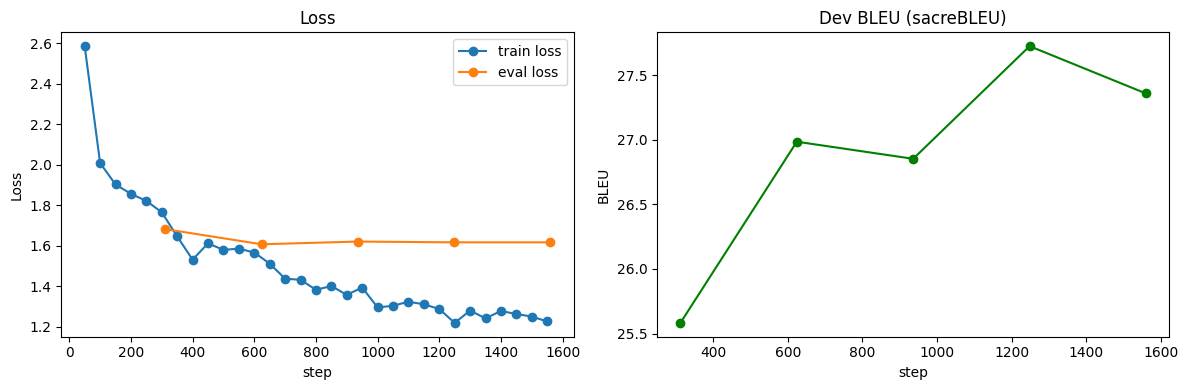

In [ ]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history

tr = [(h["step"], h["loss"]) for h in hist if "loss" in h and "eval_loss" not in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
if tr:
    ax[0].plot(*zip(*tr), marker="o", label="train loss")
if ev:
    ax[0].plot(*zip(*ev), marker="o", label="eval loss")
ax[0].set_xlabel("step"); ax[0].set_ylabel("Loss")
ax[0].legend(); ax[0].set_title("Loss")

bl = [(h["step"], h["eval_BLEU"]) for h in hist if "eval_BLEU" in h]
if bl:
    ax[1].plot(*zip(*bl), marker="o", color="green", label="BLEU")
    ax[1].set_title("Dev BLEU (sacreBLEU)")
    ax[1].set_xlabel("step"); ax[1].set_ylabel("BLEU")
else:
    ax[1].text(0.5, 0.5, "SEE EVAL_WITH_GENERATE=True to log dev BLEU",
               ha="center", va="center")
    ax[1].set_axis_off()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()


In [23]:
import glob

def _find_state_dict_file(ckpt_dir):
    for fname in ["model.safetensors", "pytorch_model.bin",
                  "adapter_model.safetensors", "adapter_model.bin"]:
        p = os.path.join(ckpt_dir, fname)
        if os.path.exists(p):
            return p
    return None

def average_checkpoints(output_dir, n):
    """Average the weights of the last n epoch checkpoints saved by the Trainer.
    Cheap and usually worth a small, free BLEU/BERTScore bump. Requires
    save_total_limit >= n during training (set via CKPT_AVERAGE_LAST_N)."""
    ckpts = sorted(
        glob.glob(os.path.join(output_dir, "checkpoint-*")),
        key=lambda p: int(p.split("-")[-1])
    )
    if len(ckpts) < 2:
        print(f"Only {len(ckpts)} checkpoint(s) found under {output_dir}; skipping averaging.")
        return None
    use = ckpts[-n:]
    print(f"Averaging {len(use)} checkpoints: {[os.path.basename(c) for c in use]}")

    state_dicts = []
    for c in use:
        f = _find_state_dict_file(c)
        if f is None:
            print(f"  no weight file found in {c}; skipping averaging.")
            return None
        if f.endswith(".safetensors"):
            from safetensors.torch import load_file
            sd = load_file(f)
        else:
            sd = torch.load(f, map_location="cpu")
        state_dicts.append(sd)

    avg_sd = {}
    for k in state_dicts[0]:
        tensors = [sd[k].float() for sd in state_dicts]
        avg_sd[k] = torch.stack(tensors, dim=0).mean(dim=0).to(state_dicts[0][k].dtype)

    avg_dir = output_dir.rstrip("/") + "_avg"
    os.makedirs(avg_dir, exist_ok=True)
    skip = {"model.safetensors", "pytorch_model.bin", "adapter_model.safetensors",
            "adapter_model.bin", "optimizer.pt", "scheduler.pt", "rng_state.pth",
            "trainer_state.json"}
    for fname in os.listdir(use[-1]):
        if fname not in skip:
            shutil.copy(os.path.join(use[-1], fname), os.path.join(avg_dir, fname))

    src_fname = os.path.basename(_find_state_dict_file(use[-1]))
    if src_fname.endswith(".safetensors"):
        from safetensors.torch import save_file
        save_file(avg_sd, os.path.join(avg_dir, src_fname))
    else:
        torch.save(avg_sd, os.path.join(avg_dir, src_fname))

    print(f"Averaged checkpoint written to {avg_dir}")
    return avg_dir

import shutil
avg_dir = None
if CONFIG.get("CKPT_AVERAGE_LAST_N", 1) > 1:
    avg_dir = average_checkpoints(CONFIG["OUTPUT_DIR"], CONFIG["CKPT_AVERAGE_LAST_N"])

if CONFIG["USE_LORA"]:
    if avg_dir is not None and _find_state_dict_file(avg_dir) is not None \
            and "adapter" in os.path.basename(_find_state_dict_file(avg_dir)):
        # reload a fresh base model and attach the averaged LoRA adapter
        from peft import PeftModel
        base = AutoModelForSeq2SeqLM.from_pretrained(
            CONFIG["MODEL_ID"], trust_remote_code=True
        ).to(DEVICE)
        model = PeftModel.from_pretrained(base, avg_dir).to(DEVICE)
    merged = model.merge_and_unload()     # fold LoRA into base weights
    merged.save_pretrained(CONFIG["MERGED_DIR"])
    tokenizer.save_pretrained(CONFIG["MERGED_DIR"])
    for var_name in ["model", "merged", "trainer"]:
        if var_name in globals():
            del globals()[var_name]
            print(f"Deleted {var_name}")
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    model = AutoModelForSeq2SeqLM.from_pretrained(
        CONFIG["MERGED_DIR"], trust_remote_code=True, attn_implementation="eager"
    ).to(DEVICE)
else:
    if avg_dir is not None:
        # use averaged full-model weights instead of just the last checkpoint
        tokenizer.save_pretrained(avg_dir)
        model = AutoModelForSeq2SeqLM.from_pretrained(
            avg_dir, trust_remote_code=True
        ).to(DEVICE)
        model.save_pretrained(CONFIG["MERGED_DIR"])
        tokenizer.save_pretrained(CONFIG["MERGED_DIR"])
    else:
        # When NOT using LoRA and no averaging, load the fine-tuned model from training
        trainer.save_model(CONFIG["MERGED_DIR"])
        tokenizer.save_pretrained(CONFIG["MERGED_DIR"])
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    model = AutoModelForSeq2SeqLM.from_pretrained(
        CONFIG["MERGED_DIR"], trust_remote_code=True, attn_implementation="eager"
    ).to(DEVICE)

model.eval()
tot, trainable = count_params(model)
print(f"Fine-tuned model TOTAL parameters: {tot:,} (~{tot/1e6:.1f}M)")
print(f"Fine-tuned model TRAINABLE parameters: {trainable:,} (~{trainable/1e6:.1f}M)")


Loading adapter weights from it2_san_en_merged led to missing keys in the model: model.encoder.layers.0.self_attn.k_proj.lora_A.default.weight, model.encoder.layers.0.self_attn.k_proj.lora_B.default.weight, model.encoder.layers.0.self_attn.v_proj.lora_A.default.weight, model.encoder.layers.0.self_attn.v_proj.lora_B.default.weight, model.encoder.layers.0.self_attn.q_proj.lora_A.default.weight, model.encoder.layers.0.self_attn.q_proj.lora_B.default.weight, model.encoder.layers.0.self_attn.out_proj.lora_A.default.weight, model.encoder.layers.0.self_attn.out_proj.lora_B.default.weight, model.encoder.layers.1.self_attn.k_proj.lora_A.default.weight, model.encoder.layers.1.self_attn.k_proj.lora_B.default.weight, model.encoder.layers.1.self_attn.v_proj.lora_A.default.weight, model.encoder.layers.1.self_attn.v_proj.lora_B.default.weight, model.encoder.layers.1.self_attn.q_proj.lora_A.default.weight, model.encoder.layers.1.self_attn.q_proj.lora_B.default.weight, model.encoder.layers.1.self_attn.

Fine-tuned model TOTAL parameters: 215,319,552 (~215.3M)
Fine-tuned model TRAINABLE parameters: 3,538,944 (~3.5M)


In [24]:
sweep_n = min(300, len(dev_df))
sub_sa = dev_df["Sentence_sa"].tolist()[:sweep_n]
sub_ref = dev_df["Sentence_en"].tolist()[:sweep_n]

# ---- stage 1: beams x length_penalty (default no_repeat_ngram) ----
grid = [(b, lp) for b in (1, 4, 5 ,6 ,8) for lp in (0.8, 1.0, 1.2, 1.4 , 1.6 ,2.0)]
results = []
for beams, lp in grid:
    preds, dt, sps = timed_translate(
        sub_sa, batch_size=CONFIG["EVAL_BS"],
        num_beams=beams, length_penalty=lp
    )
    bleu = bleu_nltk(preds, sub_ref)["bleu_corpus"]
    results.append((beams, lp, sps, bleu))
    print(f"beams={beams} len_pen={lp:.1f} -> BLEU={bleu:.4f} ({sps:.1f} sent/s)")

best = max(results, key=lambda r: r[3])  # maximize BLEU
CONFIG["NUM_BEAMS"], CONFIG["LENGTH_PENALTY"] = best[0], best[1]
print(f"\nBest beams/length_penalty on dev: beams={best[0]} length_penalty={best[1]} (BLEU={best[3]:.4f})")

# ---- stage 2: no_repeat_ngram_size, fixing beams/length_penalty at their best values ----
ngram_results = []
for ngram in CONFIG.get("NO_REPEAT_NGRAM_GRID", [CONFIG["NO_REPEAT_NGRAM"]]):
    preds, dt, sps = timed_translate(
        sub_sa, batch_size=CONFIG["EVAL_BS"],
        num_beams=CONFIG["NUM_BEAMS"], length_penalty=CONFIG["LENGTH_PENALTY"],
        no_repeat_ngram=ngram
    )
    bleu = bleu_nltk(preds, sub_ref)["bleu_corpus"]
    ngram_results.append((ngram, sps, bleu))
    print(f"no_repeat_ngram_size={ngram} -> BLEU={bleu:.4f} ({sps:.1f} sent/s)")

best_ngram = max(ngram_results, key=lambda r: r[2])
CONFIG["NO_REPEAT_NGRAM"] = best_ngram[0]
print(f"\nBest no_repeat_ngram_size on dev: {best_ngram[0]} (BLEU={best_ngram[2]:.4f})")
print(f"\nFinal decoding config: beams={CONFIG['NUM_BEAMS']} "
      f"length_penalty={CONFIG['LENGTH_PENALTY']} no_repeat_ngram_size={CONFIG['NO_REPEAT_NGRAM']}")


The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['ear

beams=1 len_pen=0.8 -> BLEU=0.1882 (11.6 sent/s)


The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not va

beams=1 len_pen=1.0 -> BLEU=0.1882 (11.7 sent/s)


The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['ear

...

beams=1 len_pen=1.4 -> BLEU=0.1882 (11.5 sent/s)


The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['ear

beams=1 len_pen=1.6 -> BLEU=0.1882 (11.5 sent/s)


The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['ear

beams=1 len_pen=2.0 -> BLEU=0.1882 (11.6 sent/s)
beams=4 len_pen=0.8 -> BLEU=0.1960 (8.6 sent/s)
beams=4 len_pen=1.0 -> BLEU=0.1990 (8.8 sent/s)
beams=4 len_pen=1.2 -> BLEU=0.1988 (8.7 sent/s)
beams=4 len_pen=1.4 -> BLEU=0.1997 (8.6 sent/s)
beams=4 len_pen=1.6 -> BLEU=0.2002 (8.4 sent/s)
beams=4 len_pen=2.0 -> BLEU=0.1994 (8.4 sent/s)
beams=5 len_pen=0.8 -> BLEU=0.1969 (7.7 sent/s)
beams=5 len_pen=1.0 -> BLEU=0.1991 (7.9 sent/s)
beams=5 len_pen=1.2 -> BLEU=0.1995 (8.0 sent/s)
beams=5 len_pen=1.4 -> BLEU=0.2005 (7.8 sent/s)
beams=5 len_pen=1.6 -> BLEU=0.2026 (7.9 sent/s)
beams=5 len_pen=2.0 -> BLEU=0.2031 (8.0 sent/s)
beams=6 len_pen=0.8 -> BLEU=0.1958 (7.3 sent/s)
beams=6 len_pen=1.0 -> BLEU=0.1976 (7.3 sent/s)
beams=6 len_pen=1.2 -> BLEU=0.1983 (7.2 sent/s)
beams=6 len_pen=1.4 -> BLEU=0.2011 (7.3 sent/s)
beams=6 len_pen=1.6 -> BLEU=0.2033 (7.4 sent/s)
beams=6 len_pen=2.0 -> BLEU=0.2039 (7.5 sent/s)
beams=8 len_pen=0.8 -> BLEU=0.1954 (5.1 sent/s)
beams=8 len_pen=1.0 -> BLEU=0.1988 (4.3

In [ ]:

if CONFIG.get("FINAL_REFIT_ON_TRAIN_DEV", False):
    print("Running final refit on train + dev ...")

    combined_df = pd.concat([train_df, dev_df], ignore_index=True)
    combined_ds = build_dataset(combined_df).map(
        tokenize_fn, batched=True, remove_columns=["sentence_SRC", "sentence_TGT"]
    )

    # fresh base model so the refit starts from the same pretrained checkpoint
    del model
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    refit_model = load_it21(CONFIG["MODEL_ID"]).to(DEVICE)

    if hasattr(refit_model, "set_label_smoothing"):
        refit_model.set_label_smoothing(CONFIG["LABEL_SMOOTHING"])
        _refit_ls = 0
    else:
        _refit_ls = CONFIG["LABEL_SMOOTHING"]

    if CONFIG["USE_LORA"]:
        refit_lora_cfg = LoraConfig(
            r=CONFIG["LORA_R"], lora_alpha=CONFIG["LORA_ALPHA"],
            lora_dropout=CONFIG["LORA_DROPOUT"], bias="none",
            task_type="SEQ_2_SEQ_LM", inference_mode=False,
            target_modules=CONFIG["LORA_TARGETS"]
        )
        refit_model = get_peft_model(refit_model, refit_lora_cfg)
        refit_model.print_trainable_parameters()
        refit_lr = CONFIG["LR_LORA"]
    else:
        refit_lr = CONFIG["LR_FULL_FT"]

    refit_collator = DataCollatorForSeq2Seq(
        tokenizer=tokenizer, model=refit_model, padding="longest",
        pad_to_multiple_of=8, label_pad_token_id=-100
    )

    refit_args = Seq2SeqTrainingArguments(
        output_dir=CONFIG["OUTPUT_DIR"] + "_final_refit",
        overwrite_output_dir=True,
        num_train_epochs=CONFIG["FINAL_REFIT_EPOCHS"],
        per_device_train_batch_size=CONFIG["TRAIN_BS"],
        gradient_accumulation_steps=CONFIG["GRAD_ACCUM"],
        learning_rate=refit_lr, lr_scheduler_type="cosine",
        warmup_ratio=CONFIG["WARMUP_RATIO"],
        label_smoothing_factor=_refit_ls,
        fp16=(DEVICE == "cuda" and CONFIG["PRECISION"] == "fp16"),
        bf16=(DEVICE == "cuda" and CONFIG["PRECISION"] == "bf16"),
        dataloader_num_workers=2, dataloader_pin_memory=(DEVICE == "cuda"),
        gradient_checkpointing=CONFIG["GRAD_CKPT"],
        logging_steps=50, save_strategy="no",  # no held-out set left to select checkpoints on
        group_by_length=True, report_to="none", seed=CONFIG["SEED"]
    )

    refit_trainer = CustomSeq2SeqTrainer(
        model=refit_model, args=refit_args, data_collator=refit_collator,
        train_dataset=combined_ds
    )
    refit_trainer.train()

    if CONFIG["USE_LORA"]:
        model = refit_model.merge_and_unload()
    else:
        model = refit_model
    model.eval()
    tot, trainable = count_params(model)
    print(f"Final refit model TOTAL parameters: {tot:,} (~{tot/1e6:.1f}M)")
else:
    print("FINAL_REFIT_ON_TRAIN_DEV is False -- keeping the train-only fine-tuned model.")


FINAL_REFIT_ON_TRAIN_DEV is False -- keeping the train-only fine-tuned model.


In [26]:
dev_preds, dev_time, dev_sps = timed_translate(
    dev_df["Sentence_sa"].tolist(),
    batch_size=CONFIG["EVAL_BS"],
    num_beams=CONFIG["NUM_BEAMS"],
    length_penalty=CONFIG["LENGTH_PENALTY"]
)
print(f"Fine-tuned dev inference: {dev_time:.1f}s")

dev_scores = report(
    dev_preds,
    dev_df["Sentence_en"].tolist(),
    seconds=dev_time,
    model_for_params=model,
    do_bertscore=True,
    tag="fine-tuned dev"
)

print("\n --- BEFORE vs AFTER (dev) ---")
print(f"BLEU(corpus): {baseline_scores['bleu_corpus']:.1f} -> {dev_scores['bleu_corpus']:.1f}")
print(f"BERTScore-F1: {baseline_scores['bertscore_f1']:.1f} -> {dev_scores['bertscore_f1']:.1f}")


Fine-tuned dev inference: 277.6s


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



 --- BEFORE vs AFTER (dev) ---
BLEU(corpus): 0.2 -> 0.2
BERTScore-F1: 0.5 -> 0.5


In [27]:
# --- generate + time on the test set ---
test_preds, test_time, test_sps = timed_translate(
    test_df["Sentence_sa"].tolist(),
    batch_size=CONFIG["EVAL_BS"]
)

# --- write submission.csv (exact required format) ---
submission = pd.DataFrame({
    "Source_id": test_df["Source_id"],
    "Sentence_en": test_preds
})
submission.to_csv("submission.csv", index=False, encoding="utf-8")
print(f"Wrote submission.csv ({len(submission)} rows)")

# --- efficiency report (required) ---
tot, _ = count_params(model)
print(f"EFFICIENCY (test) = {test_time:.2f}s ({test_sps:.2f} sentences/s)")
print(f"Total parameters = {tot:,} ({tot/1e6:.1f}M)")

# --- quality on the public test (reference, if available) ---
if "Sentence_en" in dev_df.columns:
    mask = dev_df["Sentence_en"].notna()
    dev_scores = report(
        [p for p, m in zip(dev_preds, mask) if m],
        dev_df.loc[mask, "Sentence_en"],
        seconds=dev_time,
        model_for_params=model,
        do_bertscore=True,
        tag="dev"
    )

if "Sentence_en" in test_df.columns:
    mask = test_df["Sentence_en"].notna()
    test_scores = report(
        [p for p, m in zip(test_preds, mask) if m],
        test_df.loc[mask, "Sentence_en"],
        seconds=test_time,
        model_for_params=model,
        do_bertscore=True,
        tag="test"
    )




Wrote submission.csv (1000 rows)
EFFICIENCY (test) = 276.26s (3.62 sentences/s)
Total parameters = 215,319,552 (215.3M)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
print_summary(dev_scores=dev_scores, test_scores=test_scores, model_for_params=model)

Total Parameters (full model)   : 215,319,552
Trainable Parameters (fine-tuned): 3,538,944
Inference Time (Dev)            : 277.59 sec
Inference Time (Test)           : 276.26 sec
Dev BLEU (NLTK corpus)          : 0.2043
Dev BERTScore (F1)              : 0.5244
Test BLEU (NLTK corpus)         : 0.1834
Test BERTScore (F1)             : 0.5057


In [29]:
import random as _
_.seed(CONFIG["SEED"])
ids = _.sample(range(len(test_df)), k=min(10, len(test_df)))

def quick_flags(src, ref, pred):
    flags = []
    if re.search(r"[\u0900-\u097F]", pred):
        flags.append("untranslated-Devanagari")
    lr = len(pred.split())/max(1,len(ref.split()))
    if lr<0.6:
        flags.append("too-short")
    if lr>1.6:
        flags.append("too-long")
    if not pred.strip(): flags.append("empty")
    return ", ".join(flags) if flags else "ok"

for k, i in enumerate(ids, 1):
    src = test_df["Sentence_sa"].iloc[i]
    ref = test_df["Sentence_en"].iloc[i] if "Sentence_en" in test_df.columns else "[no ref]"
    pred = test_preds[i]
    print(f"{k}) SOURCE     : {src}")
    print(f"   REFERENCE  : {ref}")
    print(f"   PREDICTION : {pred}")
    print(f"   FLAGS      : {quick_flags(src, ref, pred)}")


1) SOURCE     : इदं File Browser इति गवाक्षम् उद्घाटयति।
   REFERENCE  : This will open the file browser.
   PREDICTION : This opens the File Browser window.
   FLAGS      : ok
2) SOURCE     : वयमधुना Service tax संयोजयाम । तत्पूर्वम् अस्माभिः Service tax इत्यस्मै GL Account रचितव्यम् ।
   REFERENCE  : Now let us add Service tax. Before that we have to create a GL Account for Service tax.
   PREDICTION : Let's now add the service tax. First, we need to create a GL account for Service Tax.
   FLAGS      : ok
3) SOURCE     : भवन्त: काञ्चन कीटकान तथा अन्यतत्सदृ शान अवरोद्धुं शक्नुवन्ति ।
   REFERENCE  : "You can prevent some pests by keeping the garden free from weeds, refuse and by installing barriers and traps."
   PREDICTION : You may be able to block some insects and other pests.
   FLAGS      : too-short
4) SOURCE     : ते देशम् असेवन्त ।
   REFERENCE  : They served the country.
   PREDICTION : They were the country.
   FLAGS      : ok
5) SOURCE     : किन्तु नोन्-स्टेटिक्-ब्लोक्-इतीद